# CEO-letter specificity and abnormal equity returns — US insurers

This integration uses frozen **existing** outputs from the specificity and event-study work. It does not rerun the classifier, construct replacement CARs, or modify either upstream notebook/branch.

Primary outcomes: signed CAR[-1,+1] and absolute CAR[-1,+1]. Prespecified models: pooled, firm FE, firm + fiscal-year FE. Preferred specification: firm + fiscal-year FE. Associations are not causal.

The executable implementation lives in `specificity_car_test/analysis.py`; inputs, hashes, diagnostics and a full report are saved alongside it. Run from the repository root after installing `specificity_car_test/requirements.txt`.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
assert (ROOT / 'specificity_car_test' / 'analysis.py').exists(), 'Run from repository root'
sys.path.insert(0, str(ROOT))
from specificity_car_test.analysis import (
    load_and_audit, audit_event_prices, descriptives, regressions, plot, report, OUT, BASE
)
import pandas as pd

## 1. Source definition and merge audit — before estimation

`Specificity_mean` is the existing mean tier across **Corporate** ESG sentences with tier ≥1, combining E and S/G. It excludes contextual and false-positive sentences. Empty populations remain missing. We use the contemporaneous letter fiscal year, without the lag used in earlier valuation regressions.

All input duplicates and unmatched keys are reported. The merged export retains all 84 event rows. The source narrative export is checked against the committed 238-row specificity panel before use.

In [2]:
merged, sample, audit = load_and_audit()
display(pd.read_csv(OUT / "unmatched_company_years.csv"))

MERGE AUDIT (before estimation)
 {
  "event_input_rows": 84,
  "specificity_input_rows": 238,
  "narrative_input_rows": 238,
  "matched": 65,
  "event_only": 19,
  "specificity_only_outside_scope": 173,
  "duplicates": 0,
  "undefined_specificity_in_matched": 3,
  "pooled_N": 62,
  "specificity_mean": 1.4395261366872034,
  "specificity_sd_ddof1": 0.22955588313622707,
  "specificity_definition": "Mean tier among Corporate ESG sentences with tier >= 1; E and S/G combined. No lag.",
  "branch_drive_specificity_match": true
}

Every excluded event
                     Company  Fiscal Year                                             exclusion_reason
                      Chubb         2012 Specificity undefined: no qualifying corporate ESG sentences
              MetLife, Inc.         2013 Specificity undefined: no qualifying corporate ESG sentences
              MetLife, Inc.         2014 Specificity undefined: no qualifying corporate ESG sentences
              MetLife, Inc.         2015 

,Company,Fiscal Year,_merge,reason
0,AXA,2016,right_only,Specificity firm-year outside seven-firm event...
1,AXA,2017,right_only,Specificity firm-year outside seven-firm event...
2,AXA,2018,right_only,Specificity firm-year outside seven-firm event...
3,AXA,2019,right_only,Specificity firm-year outside seven-firm event...
4,AXA,2020,right_only,Specificity firm-year outside seven-firm event...
...,...,...,...,...
187,Zurich,2019,right_only,Specificity firm-year outside seven-firm event...
188,Zurich,2020,right_only,Specificity firm-year outside seven-firm event...
189,Zurich,2021,right_only,Specificity firm-year outside seven-firm event...
190,Zurich,2022,right_only,Specificity firm-year outside seven-firm event...


## 2. Independently verify saved CARs and date coverage

Reproduce every saved row using the archived adjusted prices, a common URTH calendar, complete event windows and an independent market-model calculation. Saved CARs are never replaced.

In [3]:
event_checks = audit_event_prices(merged)
display(pd.read_csv(OUT / "price_coverage.csv"))
display(event_checks)

Independently reproduced 84 saved event rows; max CAR error 7.01e-16; shifted dates: 4


,ticker,first_date,last_date,rows
0,AIG,2011-01-03,2024-07-30,3415
1,CB,2011-01-03,2024-07-30,3415
2,MET,2011-01-03,2024-07-30,3415
3,PRU,2011-01-03,2024-07-30,3415
4,ALL,2011-01-03,2024-07-30,3415
5,PGR,2011-01-03,2024-07-30,3415
6,TRV,2011-01-03,2024-07-30,3415
7,URTH,2012-01-12,2024-07-30,3156


,Company,Fiscal Year,original_event_date,adjusted_event_date,shifted,estimation_N,max_CAR_absolute_error
0,American International Group (AIG),2012,2013-04-01,2013-04-01,False,221,1.804112e-16
1,American International Group (AIG),2013,2014-04-02,2014-04-02,False,221,9.714451e-17
2,American International Group (AIG),2014,2015-03-31,2015-03-31,False,221,9.454243e-17
3,American International Group (AIG),2015,2016-04-01,2016-04-01,False,221,7.806256e-17
4,American International Group (AIG),2016,2017-04-03,2017-04-03,False,221,1.040834e-16
...,...,...,...,...,...,...,...
79,"The Travelers Companies, Inc.",2019,2020-04-10,2020-04-13,True,221,1.925543e-16
80,"The Travelers Companies, Inc.",2020,2021-04-09,2021-04-09,False,221,3.001072e-16
81,"The Travelers Companies, Inc.",2021,2022-04-08,2022-04-08,False,221,2.602085e-16
82,"The Travelers Companies, Inc.",2022,2023-04-14,2023-04-14,False,221,5.551115e-17


## 3. Describe associations

Pearson/Spearman correlations are descriptive. Their ordinary p-values do not account for the panel structure.

In [4]:
correlations = descriptives(merged, sample)
display(pd.read_csv(OUT / "descriptive_statistics.csv"))


Descriptive correlations (p-values assume independent observations)
      outcome   method  N  correlation  p_value_iid_descriptive
  CAR[-1,+1]  Pearson 62    -0.056154                 0.664653
  CAR[-1,+1] Spearman 62    -0.099825                 0.440140
|CAR|[-1,+1]  Pearson 62    -0.020159                 0.876411
|CAR|[-1,+1] Spearman 62    -0.085233                 0.510110
  CAR[-2,+2]  Pearson 62    -0.125364                 0.331617
  CAR[-2,+2] Spearman 62    -0.152799                 0.235766
   CAR[0,+1]  Pearson 62    -0.136393                 0.290487
   CAR[0,+1] Spearman 62    -0.132361                 0.305118


,variable,count,mean,std,min,25%,50%,75%,max,sample
0,"CAR[-1,+1]",84.0,-0.003759,0.022636,-0.108074,-0.010640,-0.002777,0.006845,0.041168,all_events
1,"|CAR|[-1,+1]",84.0,0.015069,0.017231,0.000344,0.004095,0.008928,0.019052,0.108074,all_events
2,"CAR[-2,+2]",84.0,-0.003468,0.025818,-0.157925,-0.013793,-0.004850,0.006060,0.053135,all_events
3,"CAR[0,+1]",84.0,-0.001363,0.016043,-0.066438,-0.008302,-0.001318,0.005840,0.048747,all_events
4,Specificity_mean,62.0,1.439526,0.229556,1.000000,1.297619,1.439614,1.575549,2.000000,all_events
5,total_sent,65.0,155.984615,125.354933,16.000000,71.000000,112.000000,187.000000,512.000000,all_events
6,ESGSentiment_Corporate,62.0,0.446594,0.223751,0.000000,0.338710,0.428119,0.555556,1.000000,all_events
7,"CAR[-1,+1]",62.0,-0.004319,0.023535,-0.108074,-0.011677,-0.002793,0.006452,0.041168,regression_eligible
8,"|CAR|[-1,+1]",62.0,0.015576,0.018062,0.000344,0.004232,0.008904,0.021411,0.108074,regression_eligible
9,"CAR[-2,+2]",62.0,-0.003347,0.027896,-0.157925,-0.013817,-0.004850,0.006295,0.053135,regression_eligible


## 4. Prespecified regressions, influence, and sensitivities

HC3 is the main conventional inference (t reference with residual degrees of freedom). Firm-clustered CR1 uses a finite-sample correction and t(G−1). Null-imposed WCR11 wild-cluster tests enumerate all Rademacher patterns. Few-cluster uncertainty remains.

MetLife has only one eligible year: retain it in pooled models, explicitly exclude it as a singleton in firm-FE models, and report the resulting six clusters. No outliers are removed from main models. Diagnostics include studentized residuals, Cook's distance, leverage and specificity DFBETAs.

Separate preferred-model sensitivities remove (1) the single highest-Cook's-distance row and (2) events published March 1–April 30, 2020. One optional controls model adds existing log sentence count and corporate ESG sentiment. Standardization uses the fixed 62-row pooled sample SD (ddof=1).

In [5]:
results, influence, wild, fitted = regressions(sample)
display(results[(results.predictor == 'Specificity_mean') & (results.covariance == 'HC3')])
display(wild)
display(pd.read_csv(OUT / 'model_singleton_exclusions.csv'))
display(influence[influence.specification.eq('firm_year_FE')].sort_values('cooks_distance', ascending=False).groupby('outcome').head(5))

,outcome,specification,scenario,predictor,covariance,N,firms,years,coefficient,SE,p_value,CI95_low,CI95_high,R_squared,inference_df,controls,standardization
0,"CAR[-1,+1]",pooled,main,Specificity_mean,HC3,62,7,12,-0.005757,0.008000,0.474527,-0.021759,0.010245,0.003153,60.0,,none
4,"CAR[-1,+1]",firm_FE,main,Specificity_mean,HC3,61,6,12,-0.019322,0.015040,0.204372,-0.049475,0.010831,0.138789,54.0,,none
8,"CAR[-1,+1]",firm_year_FE,main,Specificity_mean,HC3,61,6,12,-0.021111,0.021455,0.330649,-0.064380,0.022158,0.315202,43.0,,none
12,"|CAR|[-1,+1]",pooled,main,Specificity_mean,HC3,62,7,12,-0.001586,0.006678,0.813063,-0.014944,0.011772,0.000406,60.0,,none
16,"|CAR|[-1,+1]",firm_FE,main,Specificity_mean,HC3,61,6,12,0.008786,0.012064,0.469577,-0.015401,0.032973,0.071014,54.0,,none
20,"|CAR|[-1,+1]",firm_year_FE,main,Specificity_mean,HC3,61,6,12,0.010716,0.015366,0.489344,-0.020274,0.041705,0.380935,43.0,,none
24,"CAR[-2,+2]",firm_year_FE,main,Specificity_mean,HC3,61,6,12,-0.034089,0.028431,0.237086,-0.091424,0.023247,0.254627,43.0,,none
28,"CAR[0,+1]",firm_year_FE,main,Specificity_mean,HC3,61,6,12,-0.015991,0.015601,0.311083,-0.047452,0.015471,0.215596,43.0,,none
32,"CAR[-1,+1]",firm_year_FE,exclude_most_influential,Specificity_mean,HC3,60,6,12,-0.005833,0.013992,0.678875,-0.034071,0.022404,0.376646,42.0,,none
36,"CAR[-1,+1]",firm_year_FE,exclude_March_April_2020,Specificity_mean,HC3,55,6,11,-0.009814,0.014172,0.492853,-0.038504,0.018876,0.435325,38.0,,none


,outcome,specification,scenario,N,firms,p_value,method,weight_patterns,warnings
0,"CAR[-1,+1]",pooled,main,62,7,0.890625,Null-imposed WCR11; Rademacher; full enumeration,128,"2^G < the number of boot iterations, setting f..."
1,"CAR[-1,+1]",firm_FE,main,61,6,0.531250,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
2,"CAR[-1,+1]",firm_year_FE,main,61,6,0.906250,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
3,"|CAR|[-1,+1]",pooled,main,62,7,0.859375,Null-imposed WCR11; Rademacher; full enumeration,128,"2^G < the number of boot iterations, setting f..."
4,"|CAR|[-1,+1]",firm_FE,main,61,6,0.812500,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
5,"|CAR|[-1,+1]",firm_year_FE,main,61,6,0.750000,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
6,"CAR[-2,+2]",firm_year_FE,main,61,6,0.062500,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
7,"CAR[0,+1]",firm_year_FE,main,61,6,0.375000,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
8,"CAR[-1,+1]",firm_year_FE,exclude_most_influential,60,6,0.843750,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."
9,"CAR[-1,+1]",firm_year_FE,exclude_March_April_2020,55,6,0.687500,Null-imposed WCR11; Rademacher; full enumeration,64,"2^G < the number of boot iterations, setting f..."


,Company,Fiscal Year,outcome,specification,scenario,reason
0,"MetLife, Inc.",2012,"CAR[-1,+1]",firm_FE,main,Singleton fixed-effect group; no within-group ...
1,"MetLife, Inc.",2012,"CAR[-1,+1]",firm_year_FE,main,Singleton fixed-effect group; no within-group ...
2,"MetLife, Inc.",2012,"|CAR|[-1,+1]",firm_FE,main,Singleton fixed-effect group; no within-group ...
3,"MetLife, Inc.",2012,"|CAR|[-1,+1]",firm_year_FE,main,Singleton fixed-effect group; no within-group ...
4,"MetLife, Inc.",2012,"CAR[-2,+2]",firm_year_FE,main,Singleton fixed-effect group; no within-group ...
5,"MetLife, Inc.",2012,"CAR[0,+1]",firm_year_FE,main,Singleton fixed-effect group; no within-group ...
6,"MetLife, Inc.",2012,"CAR[-1,+1]",firm_year_FE,exclude_most_influential,Singleton fixed-effect group; no within-group ...
7,"MetLife, Inc.",2012,"CAR[-1,+1]",firm_year_FE,exclude_March_April_2020,Singleton fixed-effect group; no within-group ...
8,"MetLife, Inc.",2012,"CAR[-1,+1]",firm_year_FE,existing_text_controls,Singleton fixed-effect group; no within-group ...
9,"MetLife, Inc.",2012,"|CAR|[-1,+1]",firm_year_FE,exclude_most_influential,Singleton fixed-effect group; no within-group ...


,Company,Fiscal Year,outcome,specification,residual,studentized_internal,studentized_external,cooks_distance,leverage,specificity_dfbeta
7,American International Group (AIG),2019,"|CAR|[-1,+1]",firm_year_FE,0.060181,4.234305,5.480547,0.392502,0.282665,1.304562
7,American International Group (AIG),2019,"CAR[-1,+1]",firm_year_FE,-0.079936,-4.123316,-5.240817,0.372195,0.282665,-1.247497
19,Chubb,2019,"CAR[-1,+1]",firm_year_FE,0.051425,2.590130,2.786412,0.122673,0.247632,0.076125
46,"Prudential Financial, Inc.",2022,"|CAR|[-1,+1]",firm_year_FE,0.032334,2.255693,2.374199,0.104725,0.270328,-0.250242
67,The Progressive Corporation,2019,"|CAR|[-1,+1]",firm_year_FE,-0.026179,-1.912518,-1.976061,0.102210,0.334658,-0.088183
45,"Prudential Financial, Inc.",2021,"|CAR|[-1,+1]",firm_year_FE,-0.024549,-1.741128,-1.784829,0.070145,0.294032,-0.378865
46,"Prudential Financial, Inc.",2022,"CAR[-1,+1]",firm_year_FE,-0.035821,-1.832058,-1.885721,0.069083,0.270328,0.198756
69,The Progressive Corporation,2021,"|CAR|[-1,+1]",firm_year_FE,0.020617,1.508699,1.532156,0.064227,0.336829,-0.111246
8,American International Group (AIG),2020,"CAR[-1,+1]",firm_year_FE,-0.031614,-1.642421,-1.676654,0.062062,0.292849,-0.309922
70,The Progressive Corporation,2022,"CAR[-1,+1]",firm_year_FE,0.025258,1.356466,1.370238,0.052250,0.338249,0.118096


## 5. Visual inspection and interpretation

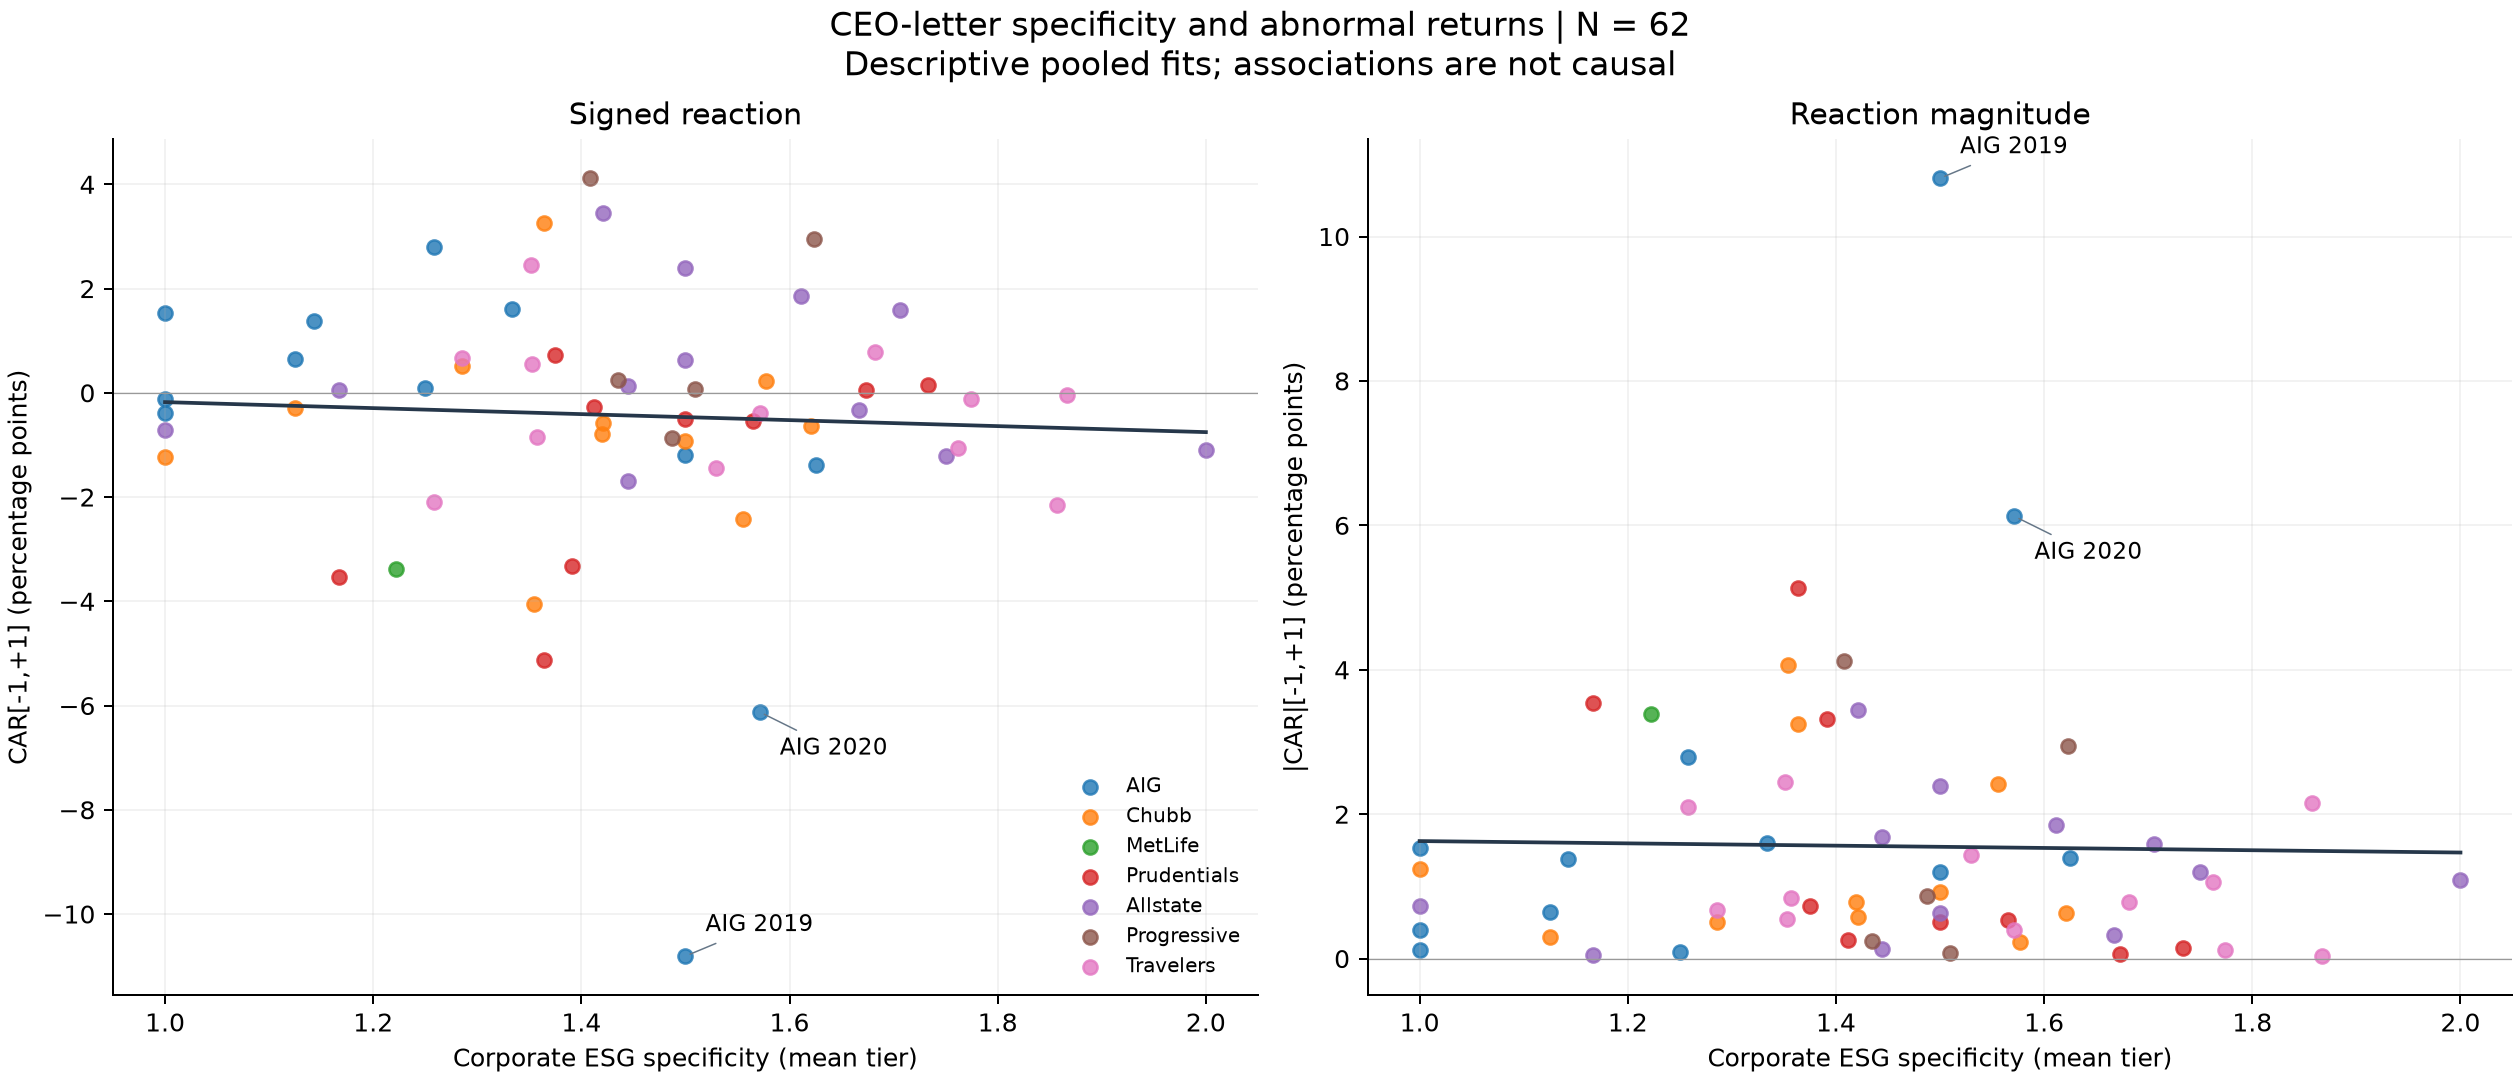

# Specificity and abnormal equity returns — US insurers

This analysis uses existing outputs; it does not rerun the classifier or modify event-study construction.
The preferred specification was fixed before estimation: firm and fiscal-year fixed effects. Publication dates determine the COVID exclusion, while fiscal years define year fixed effects.

## Measurement and provenance

`Specificity_mean` is the mean ordinal specificity tier (1 vague, 2 named/unquantified, 3 quantified) among **Corporate** ESG sentences with tier >= 1, combining E and S/G classifications. Contextual sentences and tier-0 false positives are excluded. Undefined means remain missing. This is the existing measure, not the distinct `Verified_ESG_share` or the all-relevance measure.

Source: `specificity-pipeline-3d-regression` commit `2428ae52895ffba97d280f5d776c9e88b376bfc9`, `null_check/data/panel_reg_export.csv`. All 238 specificity values (including missingness), sentence counts, and corporate sentiment agree with the original Drive `df_ar_cluster.csv`. The latter also confirms narrative coverage, so missing years are not manufactured by this integration. No valuation-model lag is carried over: each letter's own fiscal year is joined to its publication event.

CAR source: the supplied Drive `ceo_letter_event_study_panel_US.csv`, snapshotted without alteration. Event-study code at commit `6693c1d60844c31c76dc6a129cb40863dc50b05c` sets `PRICE_END = "2024-07-31"`; every saved stock series and URTH ends 2024-07-30. Raw prices independently reproduce all 84 panels' alpha, beta, estimation counts and three CAR windows within 1e-10. This checks calculations against saved inputs, not the historical accuracy of publication dates or vendor prices.

## Merge and sample

Event rows: 84; specificity rows: 238; matches: 65; event-only rows: 19; specificity-only rows: 173 (outside the seven target firms); duplicate keys: 0. Three matched rows have undefined specificity. Pooled regression N = 62. All 84 events remain in the merged CSV with eligibility and exclusion reasons. Full unmatched keys and exclusions are saved separately.

MetLife contributes only FY2012 after missing specificity is excluded. This singleton is removed explicitly from firm-FE and firm/year-FE models: it contributes no within-firm slope information and has leverage one. Main FE N = 61 and **six**, not seven, firm clusters. Model-specific removals are saved.

Specificity mean = 1.439526, sample SD = 0.229556. Standardized versions use this fixed pooled-sample mean and SD (ddof=1), also in sensitivities. CARs are decimal returns; multiply coefficients by 100 for percentage points.

## Descriptive correlations

| outcome      | method   |   N |   correlation |   p_value_iid_descriptive |
|:-------------|:---------|----:|--------------:|--------------------------:|
| CAR[-1,+1]   | Pearson  |  62 |    -0.0561536 |                  0.664653 |
| CAR[-1,+1]   | Spearman |  62 |    -0.0998249 |                  0.44014  |
| |CAR|[-1,+1] | Pearson  |  62 |    -0.0201593 |                  0.876411 |
| |CAR|[-1,+1] | Spearman |  62 |    -0.085233  |                  0.51011  |
| CAR[-2,+2]   | Pearson  |  62 |    -0.125364  |                  0.331617 |
| CAR[-2,+2]   | Spearman |  62 |    -0.152799  |                  0.235766 |
| CAR[0,+1]    | Pearson  |  62 |    -0.136393  |                  0.290487 |
| CAR[0,+1]    | Spearman |  62 |    -0.132361  |                  0.305118 |

Correlation p-values assume independent observations and are descriptive, not panel-robust inference.

## Main models: HC3 inference

| outcome      | specification   |   N |   firms |   coefficient |       SE |   p_value |   CI95_low |   CI95_high |
|:-------------|:----------------|----:|--------:|--------------:|---------:|----------:|-----------:|------------:|
| CAR[-1,+1]   | pooled          |  62 |       7 |     -0.005757 | 0.008000 |  0.474527 |  -0.021759 |    0.010245 |
| CAR[-1,+1]   | firm_FE         |  61 |       6 |     -0.019322 | 0.015040 |  0.204372 |  -0.049475 |    0.010831 |
| CAR[-1,+1]   | firm_year_FE    |  61 |       6 |     -0.021111 | 0.021455 |  0.330649 |  -0.064380 |    0.022158 |
| |CAR|[-1,+1] | pooled          |  62 |       7 |     -0.001586 | 0.006678 |  0.813063 |  -0.014944 |    0.011772 |
| |CAR|[-1,+1] | firm_FE         |  61 |       6 |      0.008786 | 0.012064 |  0.469577 |  -0.015401 |    0.032973 |
| |CAR|[-1,+1] | firm_year_FE    |  61 |       6 |      0.010716 | 0.015366 |  0.489344 |  -0.020274 |    0.041705 |
| CAR[-2,+2]   | firm_year_FE    |  61 |       6 |     -0.034089 | 0.028431 |  0.237086 |  -0.091424 |    0.023247 |
| CAR[0,+1]    | firm_year_FE    |  61 |       6 |     -0.015991 | 0.015601 |  0.311083 |  -0.047452 |    0.015471 |

Neither primary outcome shows a statistically detectable association in pooled, firm-FE, or firm/year-FE models. This is not evidence that the true association is zero: the confidence intervals are wide.

In the preferred model, the signed-CAR coefficient is −0.021111 (HC3 SE 0.021455, p=0.330649, 95% CI [−0.064380, 0.022158]). The absolute-CAR coefficient is +0.010716 (SE 0.015366, p=0.489344, CI [−0.020274, 0.041705]). A one-SD specificity increase corresponds to approximately −0.485 percentage points of signed CAR and +0.246 percentage points of absolute CAR; both intervals include zero. Magnitude's coefficient changes from slightly negative pooled to positive with firm effects, so its sign is not stable across specifications.

Alternative signed windows remain negative and nonsignificant under HC3. The five-day window has a coarse wild-cluster p-value of 0.0625, contrasting with HC3 p=0.2371; report this sensitivity without treating it as reliable confirmatory evidence.

AIG FY2019 is the most influential observation in both preferred models. Removing it reduces the signed coefficient to −0.005833 (p=0.6789) and changes the magnitude coefficient to −0.000786 (p=0.9372). Removing all March–April 2020 events gives −0.009814 (p=0.4929) and −0.000239 (p=0.9813), respectively. The magnitude estimate's positive sign and much of its size depend on these observations; the absence of conventional statistical evidence persists. The signed estimate remains negative but is materially attenuated. Existing length/tone controls likewise do not produce a statistically detectable association.

## Prespecified sensitivities: HC3 inference

| outcome      | scenario                 |   N |   firms |   coefficient |       SE |   p_value |   CI95_low |   CI95_high |
|:-------------|:-------------------------|----:|--------:|--------------:|---------:|----------:|-----------:|------------:|
| CAR[-1,+1]   | exclude_most_influential |  60 |       6 |     -0.005833 | 0.013992 |  0.678875 |  -0.034071 |    0.022404 |
| CAR[-1,+1]   | exclude_March_April_2020 |  55 |       6 |     -0.009814 | 0.014172 |  0.492853 |  -0.038504 |    0.018876 |
| CAR[-1,+1]   | existing_text_controls   |  61 |       6 |     -0.031283 | 0.024102 |  0.201551 |  -0.079957 |    0.017391 |
| |CAR|[-1,+1] | exclude_most_influential |  60 |       6 |     -0.000786 | 0.009919 |  0.937193 |  -0.020803 |    0.019231 |
| |CAR|[-1,+1] | exclude_March_April_2020 |  55 |       6 |     -0.000239 | 0.010124 |  0.981301 |  -0.020734 |    0.020256 |
| |CAR|[-1,+1] | existing_text_controls   |  61 |       6 |      0.011524 | 0.018696 |  0.541044 |  -0.026234 |    0.049283 |

## Wild-cluster inference

| outcome      | specification   | scenario                 |   N |   firms |   p_value | method                                           |   weight_patterns | warnings                                                               |
|:-------------|:----------------|:-------------------------|----:|--------:|----------:|:-------------------------------------------------|------------------:|:-----------------------------------------------------------------------|
| CAR[-1,+1]   | pooled          | main                     |  62 |       7 |  0.890625 | Null-imposed WCR11; Rademacher; full enumeration |               128 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-1,+1]   | firm_FE         | main                     |  61 |       6 |  0.531250 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-1,+1]   | firm_year_FE    | main                     |  61 |       6 |  0.906250 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | pooled          | main                     |  62 |       7 |  0.859375 | Null-imposed WCR11; Rademacher; full enumeration |               128 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | firm_FE         | main                     |  61 |       6 |  0.812500 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | firm_year_FE    | main                     |  61 |       6 |  0.750000 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-2,+2]   | firm_year_FE    | main                     |  61 |       6 |  0.062500 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[0,+1]    | firm_year_FE    | main                     |  61 |       6 |  0.375000 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-1,+1]   | firm_year_FE    | exclude_most_influential |  60 |       6 |  0.843750 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-1,+1]   | firm_year_FE    | exclude_March_April_2020 |  55 |       6 |  0.687500 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| CAR[-1,+1]   | firm_year_FE    | existing_text_controls   |  61 |       6 |  0.843750 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | firm_year_FE    | exclude_most_influential |  60 |       6 |  0.968750 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | firm_year_FE    | exclude_March_April_2020 |  55 |       6 |  0.906250 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |
| |CAR|[-1,+1] | firm_year_FE    | existing_text_controls   |  61 |       6 |  0.843750 | Null-imposed WCR11; Rademacher; full enumeration |                64 | 2^G < the number of boot iterations, setting full_enumeration to True. |

HC3 uses Student-t reference with OLS residual degrees of freedom. Firm-clustered CR1 uses the finite-sample correction and t(G−1); it is a sensitivity check, with only seven pooled clusters and six main FE clusters. HC3 does not address within-firm dependence or contemporaneous cross-firm dependence. Wild-cluster tests impose a zero-specificity-coefficient null, use WCR11 and enumerate Rademacher weights (128 patterns for seven firms; 64 for six); their p-values are coarse, and they do not eliminate few-cluster limitations. Standardized models have the same null tests. No bootstrap confidence intervals are claimed.

## Influence

| Company                            |   Fiscal Year | outcome      |   studentized_external |   cooks_distance |   leverage |   specificity_dfbeta |
|:-----------------------------------|--------------:|:-------------|-----------------------:|-----------------:|-----------:|---------------------:|
| American International Group (AIG) |          2019 | |CAR|[-1,+1] |               5.480547 |         0.392502 |   0.282665 |             1.304562 |
| American International Group (AIG) |          2019 | CAR[-1,+1]   |              -5.240817 |         0.372195 |   0.282665 |            -1.247497 |
| Chubb                              |          2019 | CAR[-1,+1]   |               2.786412 |         0.122673 |   0.247632 |             0.076125 |
| Prudential Financial, Inc.         |          2022 | |CAR|[-1,+1] |               2.374199 |         0.104725 |   0.270328 |            -0.250242 |
| The Progressive Corporation        |          2019 | |CAR|[-1,+1] |              -1.976061 |         0.102210 |   0.334658 |            -0.088183 |
| Prudential Financial, Inc.         |          2021 | |CAR|[-1,+1] |              -1.784829 |         0.070145 |   0.294032 |            -0.378865 |
| Prudential Financial, Inc.         |          2022 | CAR[-1,+1]   |              -1.885721 |         0.069083 |   0.270328 |             0.198756 |
| The Progressive Corporation        |          2021 | |CAR|[-1,+1] |               1.532156 |         0.064227 |   0.336829 |            -0.111246 |
| American International Group (AIG) |          2020 | CAR[-1,+1]   |              -1.676654 |         0.062062 |   0.292849 |            -0.309922 |
| The Progressive Corporation        |          2022 | CAR[-1,+1]   |               1.370238 |         0.052250 |   0.338249 |             0.118096 |

Influence diagnostics use conventional OLS studentization, separately from robust inference. The exclusion sensitivity removes the observation with the largest Cook’s distance in each outcome’s preferred model. COVID sensitivity separately removes publication events from March 1 through April 30, 2020 inclusive. No observation is winsorized or removed from the primary pooled sample for being an outlier. The control sensitivity adds existing log sentence count and corporate ESG sentiment; it adjusts jointly for document length and tone. Sentiment is itself part of narrative content, so this is a sensitivity specification, not an identified causal adjustment.

## Data-quality limitations

- 4 publication dates shift to the next observed URTH session. All tested event windows have complete returns.
- URTH data begin January 12, 2012, despite the January 2011 requested start. Paired estimation counts were checked directly.
- Publication dates are taken as supplied; their source documents and time-of-day have not been independently authenticated. Annual-report announcements can include other value-relevant news.
- Chubb calculations reproduce using CB only. ACE became Chubb Limited and its shares began trading as CB on January 15, 2016, per the [issuer announcement](https://investors.chubb.com/News--Events/news/news-details/2016/ACE-Completes-Acquisition-of-Chubb-Adopts-Chubb-Name-and-Launches-New-Chubb-Brand-01-14-2016/default.aspx). This establishes legal/ticker continuity, but does not independently authenticate every pre-2016 Yahoo historical quote. The upstream notebook itself asks for a historical-price spot-check; that limitation remains.
- The upstream event code drops missing firm prices before calculating returns and sums abnormal returns with default missing-value handling. The independent audit checks a common benchmark calendar, no forward filling, and complete windows; no effect on these supplied CARs was found.
- The regression sample is small and unbalanced, with limited generalizability. Multiple outcomes/specifications are reported as prespecified; no claim rests on a selected minimum p-value. No multiplicity-adjusted confirmatory claim is made.

Interpret results only as associations between narrative specificity and the direction or magnitude of abnormal equity returns surrounding publication. Signed CAR and absolute CAR answer different questions.


In [6]:
plot(sample, fitted)
display(Image(filename=str(OUT / 'specificity_CAR_scatterplots.png')))
report(audit, correlations, results, influence, wild, event_checks)
display(Markdown((BASE / 'REPORT.md').read_text()))

## 6. Completion checks

Every regression is checked against an independent partial-regression coefficient and HC3 sandwich calculation. Standardized and original fits must have equal predictions. No branch is merged into main.

In [7]:
assert len(merged) == 84
assert merged.regression_eligible.sum() == 62
assert len(event_checks) == 84
assert event_checks.max_CAR_absolute_error.max() < 1e-10
assert len(results) == 56  # 14 specifications/scenarios × 2 scales × 2 covariance estimators
assert len(wild) == 14
assert results[['coefficient','SE','p_value','CI95_low','CI95_high']].notna().all().all()
print('Validated outputs: specificity_car_US_merged.csv; specificity_car_regression_results.csv')

Validated outputs: specificity_car_US_merged.csv; specificity_car_regression_results.csv
